In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Cloning repository
!git clone https://github.com/Haz1q1105/nlp-assignment3
%cd nlp-assignment3

# Install dependencies
!pip install sentencepiece matplotlib tqdm

Mounted at /content/drive
Cloning into 'nlp-assignment3'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 2), reused 7 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 9.16 KiB | 9.16 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/nlp-assignment3


In [2]:
!git config --global user.email "haziqmubi667@gmail.com"
!git config --global user.name "Haziq Mubashir"

In [3]:
!touch test.txt

In [4]:
!git add .
!git commit -m "Test commit from Colab"

[main 85b5307] Test commit from Colab
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 test.txt


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import sentencepiece as spm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [6]:
!wget http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz

--2026-04-24 14:58:24--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 495854086 (473M) [application/x-gzip]
Saving to: ‘reviews_Electronics_5.json.gz’

reviews_Electronics 100%[===================>] 472.88M  15.2MB/s    in 36s     

2026-04-24 14:59:00 (13.0 MB/s) - ‘reviews_Electronics_5.json.gz’ saved [495854086/495854086]



In [7]:
!wget http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Books_5.json.gz

--2026-04-24 14:59:01--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Books_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3223678899 (3.0G) [application/x-gzip]
Saving to: ‘reviews_Books_5.json.gz’

reviews_Books_5.jso 100%[===================>]   3.00G  15.3MB/s    in 3m 28s  

2026-04-24 15:02:29 (14.8 MB/s) - ‘reviews_Books_5.json.gz’ saved [3223678899/3223678899]



In [8]:
!wget http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Clothing_Shoes_and_Jewelry_5.json.gz

--2026-04-24 15:02:29--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Clothing_Shoes_and_Jewelry_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47285200 (45M) [application/x-gzip]
Saving to: ‘reviews_Clothing_Shoes_and_Jewelry_5.json.gz’

reviews_Clothing_Sh 100%[===================>]  45.09M  12.6MB/s    in 6.8s    

2026-04-24 15:02:36 (6.65 MB/s) - ‘reviews_Clothing_Shoes_and_Jewelry_5.json.gz’ saved [47285200/47285200]



In [9]:
!ls -lh

total 3.6G
-rw-r--r-- 1 root root  24K Apr 24 14:58 i232579_NLP_Assignment3.ipynb
drwxr-xr-x 2 root root 4.0K Apr 24 14:58 models
drwxr-xr-x 2 root root 4.0K Apr 24 14:58 results
-rw-r--r-- 1 root root 3.1G Apr 26  2016 reviews_Books_5.json.gz
-rw-r--r-- 1 root root  46M Apr 26  2016 reviews_Clothing_Shoes_and_Jewelry_5.json.gz
-rw-r--r-- 1 root root 473M Apr 26  2016 reviews_Electronics_5.json.gz
-rw-r--r-- 1 root root    0 Apr 24 14:58 test.txt


In [10]:
import gzip
import json
from tqdm import tqdm

def load_category(file_path, max_samples=15000):
    data = []

    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(tqdm(f)):
            if i >= max_samples:
                break

            review = json.loads(line)

            # NOTE: same keys here
            if 'reviewText' in review and 'overall' in review:
                data.append((review['reviewText'], int(review['overall'])))

    return data

In [11]:
electronics = load_category("reviews_Electronics_5.json.gz")
books = load_category("reviews_Books_5.json.gz")
clothing = load_category("reviews_Clothing_Shoes_and_Jewelry_5.json.gz")

data = electronics + books + clothing

print("Total dataset size:", len(data))
print("Sample:", data[0])

15000it [00:00, 52215.20it/s]
15000it [00:00, 56900.93it/s]
15000it [00:00, 102672.56it/s]

Total dataset size: 45000
Sample: ('We got this GPS for my husband who is an (OTR) over the road trucker.  Very Impressed with the shipping time, it arrived a few days earlier than expected...  within a week of use however it started freezing up... could of just been a glitch in that unit.  Worked great when it worked!  Will work great for the normal person as well but does have the "trucker" option. (the big truck routes - tells you when a scale is coming up ect...)  Love the bigger screen, the ease of use, the ease of putting addresses into memory.  Nothing really bad to say about the unit with the exception of it freezing which is probably one in a million and that\'s just my luck.  I contacted the seller and within minutes of my email I received a email back with instructions for an exchange! VERY impressed all the way around!', 5)


In [12]:
## splitting data for preparation for RAG

import random

random.shuffle(data)

train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))

train_data = data[:train_size]
val_data = data[train_size:train_size+val_size]
test_data = data[train_size+val_size:]

print(len(train_data), len(val_data), len(test_data))

31499 6750 6751


In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

In [14]:
from collections import Counter

counter = Counter()

for text, _ in train_data:
    tokens = clean_text(text).split()
    counter.update(tokens)

vocab_size = 8000

most_common = counter.most_common(vocab_size - 2)

vocab = {"<pad>": 0, "<unk>": 1}

for word, _ in most_common:
    vocab[word] = len(vocab)

print("Vocab size:", len(vocab))

Vocab size: 8000


In [15]:
MAX_LEN = 64

def encode(text):
    text = clean_text(text)
    tokens = text.split()

    ids = [vocab.get(t, 1) for t in tokens]  # 1 = <unk>
    ids = ids[:MAX_LEN]

    ids += [0] * (MAX_LEN - len(ids))  # padding

    return ids

In [16]:
def sentiment_label(r):
    if r <= 2: return 0
    elif r == 3: return 1
    else: return 2

def review_length_feature(text):
    return 0 if len(text.split()) < 50 else 1

In [17]:
sample = train_data[0][0]

print("Original:", sample)
print("Encoded:", encode(sample))
print("Length:", len(encode(sample)))

Original: I ordered these as an anniversary present for my husband, after I heard him comment that his others were wearing out; he had really gotten his money's worth out of those.  I had to remind him of the usual two-week breaking in, and that was o.k.  They did seem just a tad longer than the others, but otherwise fit great.  Amazon's price was also better than any site also, so that encouraged me to go ahead and get them before a possible price increase.
Encoded: [6, 261, 29, 20, 39, 4823, 705, 12, 17, 352, 90, 6, 787, 193, 1752, 13, 45, 288, 76, 326, 55, 50, 58, 72, 1277, 45, 5529, 239, 55, 7, 164, 6, 58, 5, 3377, 193, 7, 2, 962, 1, 2005, 10, 3, 13, 21, 562, 25, 121, 308, 43, 4, 2398, 399, 60, 2, 288, 16, 775, 92, 42, 3452, 106, 21, 78]
Length: 64


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0)/d_model))

        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        self.heads = heads
        self.d_k = d_model // heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape

        q = self.q(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        k = self.k(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        v = self.v(x).view(B, T, self.heads, self.d_k).transpose(1,2)

        scores = (q @ k.transpose(-2,-1)) / np.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)

        out = (attn @ v).transpose(1,2).contiguous().view(B, T, D)

        return self.out(out)

In [21]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        self.attn = MultiHeadAttention(d_model, heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model*4),
            nn.ReLU(),
            nn.Linear(d_model*4, d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x

In [22]:
class EncoderModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, heads=4, layers=2):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model)

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, heads) for _ in range(layers)
        ])

        # Outputs
        self.sentiment_head = nn.Linear(d_model, 3)
        self.feature_head = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos(x)

        for layer in self.layers:
            x = layer(x)

        # pooling
        rep = x.mean(dim=1)

        sentiment = self.sentiment_head(rep)
        feature = self.feature_head(rep)

        return sentiment, feature, rep

In [23]:
def prepare_batch(batch):
    texts, ratings = zip(*batch)

    X = torch.tensor([encode(t) for t in texts]).to(device)
    y1 = torch.tensor([sentiment_label(r) for r in ratings]).to(device)
    y2 = torch.tensor([review_length_feature(t) for t in texts]).to(device)

    return X, y1, y2

In [44]:
model = EncoderModel(len(vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

train_losses = []

for epoch in range(14):
    model.train()
    total_loss = 0

    for i in range(0, len(train_data), 64):
        batch = train_data[i:i+64]
        X, y1, y2 = prepare_batch(batch)

        s_pred, f_pred, _ = model(X)

        loss = F.cross_entropy(s_pred, y1) + F.cross_entropy(f_pred, y2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (len(train_data)//64)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.6343
Epoch 2, Loss: 0.5746
Epoch 3, Loss: 0.5234
Epoch 4, Loss: 0.4839
Epoch 5, Loss: 0.4533
Epoch 6, Loss: 0.4256
Epoch 7, Loss: 0.3953
Epoch 8, Loss: 0.3611
Epoch 9, Loss: 0.3239
Epoch 10, Loss: 0.2854
Epoch 11, Loss: 0.2560
Epoch 12, Loss: 0.2219
Epoch 13, Loss: 0.1769
Epoch 14, Loss: 0.1423


In [45]:
import numpy as np

model.eval()

train_embeddings = []
train_texts = []

with torch.no_grad():
    for i in range(0, len(train_data), 64):
        batch = train_data[i:i+64]
        X, _, _ = prepare_batch(batch)

        _, _, rep = model(X)

        train_embeddings.append(rep.cpu().numpy())
        train_texts.extend([t for t, _ in batch])

train_embeddings = np.vstack(train_embeddings)

print("Embeddings shape:", train_embeddings.shape)

Embeddings shape: (31499, 128)


In [46]:
np.save("train_embeddings.npy", train_embeddings)

In [47]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

In [48]:
def retrieve(query_text, k=3):
    model.eval()

    X = torch.tensor([encode(query_text)]).to(device)

    with torch.no_grad():
        _, _, query_vec = model(X)

    query_vec = query_vec.cpu().numpy().squeeze()

    sims = np.dot(train_embeddings, query_vec)

    top_k_idx = np.argsort(sims)[-k:][::-1]

    return [train_texts[i] for i in top_k_idx]

In [49]:
query = "This product is amazing and works perfectly"

results = retrieve(query, k=3)

print("Query:", query)
print("\nTop Matches:\n")

for i, r in enumerate(results):
    print(f"{i+1}. {r}\n")

Query: This product is amazing and works perfectly

Top Matches:

1. Simple and effective.

2. Great classic!

3. works great



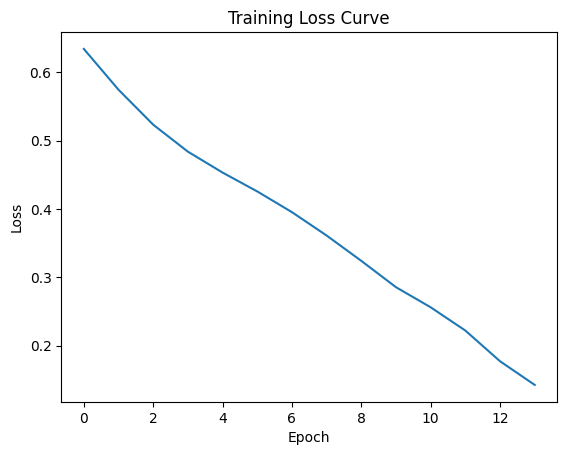

In [50]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()